# 回归模型评估

https://www.runoob.com/ml/ml-regression-model-evaluation.html

在机器学习的世界里，构建一个模型只是第一步，就像我们烤好了一个蛋糕，必须尝一尝才能知道它是否成功。对于回归模型（一种用于预测连续数值的模型，比如预测房价、气温或销售额），模型评估就是我们的品尝环节。它告诉我们模型预测得有多准，哪里做得好，哪里还有改进空间。

本文将带你系统学习回归模型的评估方法，从核心概念到具体指标，再到代码实践，让你不仅能看懂评估报告，更能亲手为你的模型"打分"。

回归模型与评估的核心概念

什么是回归问题？

回归问题是监督学习的一种，其目标是基于输入特征预测一个连续的数值。

- 例子：根据房屋的面积、房龄、地理位置（特征）来预测其售价（连续的数值）。

为什么需要评估？
- 模型选择：比较不同算法（如线性回归、决策树回归）哪个在你的数据上表现更好。
- 参数调优：调整模型参数（如正则化强度）时，需要一个客观标准来判断调整是否有效。
- 性能确认：确保模型在未知数据上也有可靠的预测能力，避免"纸上谈兵"。

关键术语：误差

所有评估指标都围绕着"误差"展开。误差是模型预测值（ŷ）与真实值（y）之间的差异。

单个点的误差：误差 = y - ŷ
评估的本质，就是用不同的方式汇总和分析这些误差。

## 核心评估指标详解

### 平均绝对误差（MAE）

通俗理解：把所有预测"误差"的绝对值加起来，然后算个平均数。它直接反映了"平均来看，预测值大概偏离真实值多少单位"。

计算公式： MAE = (1/n) * Σ|y_i - ŷ_i| 其中 n 是样本数量，Σ 是求和符号。

计算示例： MAE = (|-10| + |5| + |-10| + |20| + |-5|) / 5 = (10+5+10+20+5)/5 = 50/5 = 10

解读：平均来说，我们的房价预测偏离真实价格 10万元。

特点：

优点：直观易懂，不受极端误差值（异常值）的过度影响。
缺点：绝对值函数在数学上不是处处可导，这在某些优化场景中不太方便。

### 均方误差（MSE）

通俗理解：先把每个误差"平方"一下（让负号消失并放大误差），然后求平均值。它对大的误差非常敏感。

计算公式： MSE = (1/n) * Σ(y_i - ŷ_i)^2

计算示例： MSE = [(-10)^2 + (5)^2 + (-10)^2 + (20)^2 + (-5)^2] / 5 = (100+25+100+400+25)/5 = 650/5 = 130

解读：误差平方的平均值是130。这个数值本身没有直接的单位意义（是万元^2），但用于比较模型时非常有效。

特点：

优点：数学性质优秀（处处可导），是许多模型（如线性回归）训练时最小化的目标函数。
缺点：量纲与原始数据不同，数值大小不易解释；对异常值敏感。

### 均方根误差（RMSE）

通俗理解：就是MSE的平方根。相当于把MSE"打回原形"，让它和真实值、预测值回到同一个量纲上。

计算公式： RMSE = sqrt(MSE)

计算示例： RMSE = sqrt(130) ≈ 11.4

解读：平均来看，我们的预测大约偏离真实值 11.4万元。这个解释和MAE（10万元）类似，但RMSE因为先平方再开方，会给予大误差更高的权重，所以通常比MAE大。

特点：

优点：具有和原始数据相同的量纲，解释性比MSE强；对大误差惩罚更重，在重视大误差的场景（如金融风险预测）中很常用。
缺点：同样对异常值敏感。


### R² 分数（决定系数）

$$
R^2 = 1 - \frac{ \sum(y_i - \hat y_i)^2 }{ \sum(y_i - y_{mean})^2 }
$$

通俗理解：我的模型，比"瞎猜"（用平均值猜）强多少？它是一个比例值，衡量模型对数据变化的解释能力。

计算公式： R² = 1 - (Σ(y_i - ŷ_i)^2 / Σ(y_i - y_mean)^2) 其中 y_mean 是真实值的平均值。

"瞎猜"模型：对于任何房子，我都预测房价的平均值（y_mean）。

计算得到 y_mean = (200+150+300+400+250)/5 = 260
"瞎猜"模型的误差平方和：Σ(y_i - 260)^2 = 1600+12100+1600+19600+100 = 35000
计算示例： R² = 1 - (650 / 35000) = 1 - 0.01857 ≈ 0.9814

解读：我们的模型能够解释目标变量（房价）98.14% 的波动。这表示模型拟合得非常好。

特点：

范围：理论上，R² 的范围是 (-∞, 1]。
R² = 1：完美预测。
R² = 0：模型和直接用平均值预测的效果一样。
R² < 0：模型比直接用平均值预测还要差（说明模型完全不适合数据）。
优点：无量纲，易于比较不同数据集上的模型性能。
缺点：随着模型特征增加，R² 会自然增大，即使增加的特征没有用，这可能导致过拟合。

=== 回归模型评估报告 ===
平均绝对误差 (MAE): 0.5913
均方误差 (MSE): 0.6537
均方根误差 (RMSE): 0.8085
决定系数 (R² Score): 0.8072

模型系数：
   截距 (Intercept): 4.1429
   斜率 (Coefficient for X): 2.7993


/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63164/2839760208.py:62: UserWarning: Glyph 32654 (\N{CJK UNIFIED IDEOGRAP

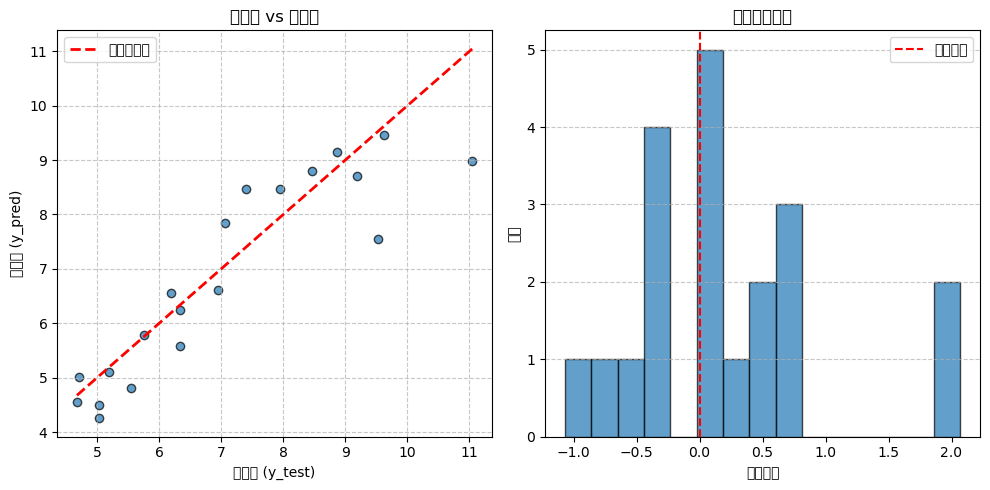

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 创建模拟数据
np.random.seed(42) # 确保每次运行结果一致
X = 2 * np.random.rand(100, 1) # 100个样本，1个特征，范围[0,2)
y = 4 + 3 * X + np.random.randn(100, 1) # 真实关系：y = 4 + 3x + 噪声

# 2. 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 训练一个简单的线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 在测试集上进行预测
y_pred = model.predict(X_test)

# 5. 计算所有评估指标
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # 或者用 mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# 6. 打印评估结果
print("=== 回归模型评估报告 ===")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"决定系数 (R² Score): {r2:.4f}")
print("\n模型系数：")
print(f"   截距 (Intercept): {model.intercept_[0]:.4f}")
print(f"   斜率 (Coefficient for X): {model.coef_[0][0]:.4f}")

# 7. 可视化结果
plt.figure(figsize=(10, 5))

# 子图1：真实值 vs 预测值散点图
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='完美预测线')
plt.xlabel('真实值 (y_test)')
plt.ylabel('预测值 (y_pred)')
plt.title('真实值 vs 预测值')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 子图2：误差分布直方图
plt.subplot(1, 2, 2)
errors = y_test.flatten() - y_pred.flatten()
plt.hist(errors, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', label='零误差线')
plt.xlabel('预测误差')
plt.ylabel('频次')
plt.title('预测误差分布')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7, axis='y')

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes

# 加载数据并合并特征和目标
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 导出为 csv
df.to_csv("diabetes.csv", index=False)